# Benchmark albireo on Gaia RVS spectra, step by step

Gaia DR4 publishes an epoch RVS spectrum for every transit of every star brighter than
about G_RVS = 12, in the barycentric frame, including the double-lined transits that the
Gaia pipeline rejects. Until those spectra are released, albireo's performance on them can
be measured only on simulations. The workflow has five steps:

1. render the spectra of two stars from a synthetic spectral library;
2. put the stars in an orbit and simulate the epoch spectra Gaia would deliver;
3. analyse that one binary and compare with the injected values;
4. draw a population of binaries as a magnitude-limited survey observes them;
5. run the benchmark over the population and read its report.

Steps 1 to 3 treat one system. Steps 4 and 5 repeat them over many, under several levels
of prior knowledge, and tabulate the errors. The key numbers of the recorded full runs, 33
systems under four tiers, are in the section "Results of the full runs" after step 5.
Background is in the [science overview](../science.md). The prose version of this page is
the [Gaia RVS tutorial](gaia-rvs.md).

Install with the plotting extra and fetch the RVS box of the BOSZ 2024 grid once (621 MB
downloaded, 5 MB kept):

```
pip install -e ".[io,plots]"
python -c "import albireo; albireo.fetch_library('bosz2024-fgk-rvs')"
```

Everything is seeded. The timings are from one run on a 32-thread desktop, and every first
call includes JAX compilation.

In [1]:
import subprocess
import sys
import tempfile
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import albireo as ab
from albireo.benchmark import collect
from albireo.gaia import (
    RVS_DR4_EPOCH,
    rvs_components,
    rvs_delivered_sigma_kms,
    rvs_model_grid,
    simulate_rvs_dataset,
    uniform_phase_times,
)
from albireo.population import (
    draw_population,
    population_summary,
    semi_amplitudes,
    write_population,
)

matplotlib.rcParams["figure.dpi"] = 110
print(f"albireo {ab.__version__}")

albireo 0.1.0.dev0


## Step 1: two stars from the library

albireo synthesises no spectra. The component spectra come from a spectral library, here
the RVS band of the BOSZ 2024 grid (Bohlin et al. 2017; Mészáros et al. 2024), rendered
at the labels of the two stars and rotationally broadened. The system is that of the
reference implementation's notebook: a 6100 K and a 5700 K dwarf, with a flux ratio of
0.60 in the RVS band.

The model grid is logarithmic in wavelength, so a velocity shift is a shift by a whole
number of pixels plus a fraction. It covers the RVS band plus a margin for the largest
velocity the analysis applies.

455 nodes, R = 20000, bounds {'teff': (4000.0, 7000.0), 'logg': (3.0, 5.0), 'mh': (-1.0, 0.5)}


model grid: 4519 pixels of 2.0 km/s from 8450.9 to 8709.5 A


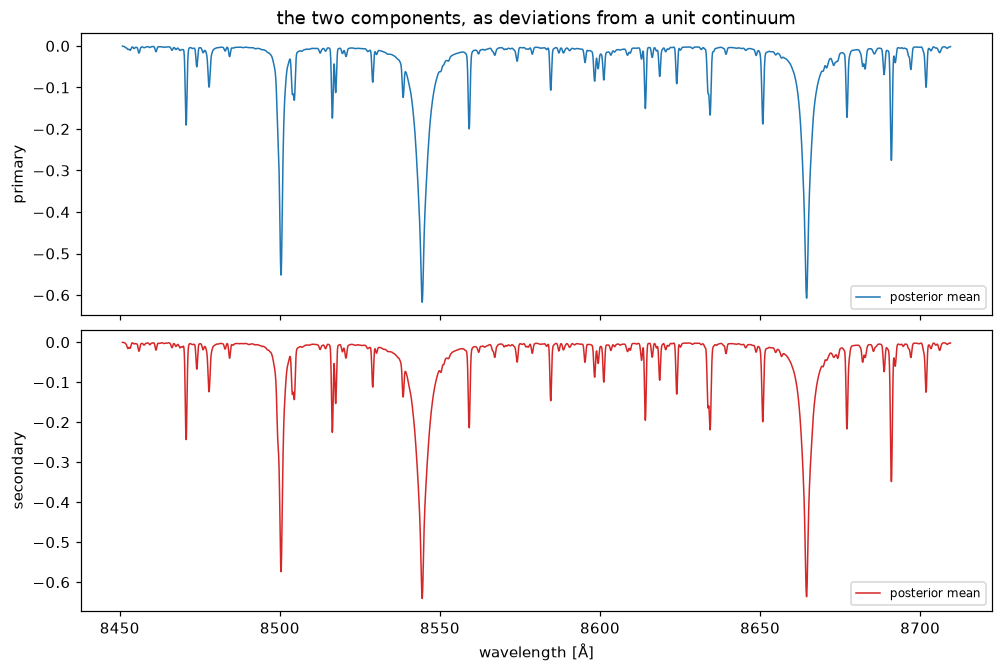

In [2]:
PRIMARY = {"teff": 6100.0, "logg": 4.2, "mh": -0.1}
SECONDARY = {"teff": 5700.0, "logg": 4.3, "mh": -0.1}
VSINI = (12.0, 11.0)  # km/s
FLUX_RATIO = 0.60  # F_secondary / F_primary in the RVS band
LIGHT = (1.0 / (1.0 + FLUX_RATIO), FLUX_RATIO / (1.0 + FLUX_RATIO))

library = ab.fetch_library("bosz2024-fgk-rvs")
print(f"{library.n_nodes} nodes, R = {library.resolving_power:.0f}, bounds {library.bounds}")

grid = rvs_model_grid(250.0, vsini_max_kms=max(VSINI))  # +-250 km/s of margin
components = rvs_components(library, [PRIMARY, SECONDARY], grid, vsini_kms=VSINI)
print(
    f"model grid: {grid.n} pixels of {grid.dv_kms:.1f} km/s "
    f"from {grid.wave[0]:.1f} to {grid.wave[-1]:.1f} A"
)

fig, axes = ab.plot_spectra(grid, np.stack(components), labels=["primary", "secondary"])
axes[0].set_title("the two components, as deviations from a unit continuum")
fig.set_layout_engine("constrained")

## Step 2: the orbit, and the epochs Gaia would deliver

The masses, the period, the eccentricity and the inclination fix the two semi-amplitudes.
`simulate_rvs_dataset` then does what the instrument and the archive do, in order. It
shifts each component to its velocity at every epoch and sums them with the light
fractions. It broadens the sum from the library's resolving power to the RVS's 11,500 and
rebins onto the detector pixels. It adds photon noise at the S/N per detector pixel and
interpolates each epoch onto the grid the archive publishes, here the DR4 epoch grid.

The archive's grid has more samples than the detector has pixels, so after the last step
neighbouring samples share noise, which the archive's per-pixel `flux_error` does not
report. The simulation records the effect of the delivery on the noise and on the line
widths, and the analysis below declares both.

In [3]:
M1, M2 = 1.30, 1.20  # solar masses
PERIOD, ECC, OMEGA, PHI0, INCL, GAMMA = 4.0, 0.10, 0.7, 1.2, np.radians(87.0), -18.0
SNR, N_EPOCHS = 40.0, 10  # per detector pixel; epochs evenly spaced over one period

k1, k2 = semi_amplitudes(M1, M2, PERIOD, ECC, INCL)
print(f"injected K1 = {k1:.2f}, K2 = {k2:.2f} km/s")
orbit = ab.OrbitParams(
    period=PERIOD, t_peri=PHI0 * PERIOD / (2 * np.pi), ecc=ECC, omega=OMEGA, k=(k1, k2), gamma=GAMMA
)

bjd = uniform_phase_times(PERIOD, N_EPOCHS, start=2457000.0)
dataset, truth = simulate_rvs_dataset(
    components,
    grid,
    bjd=bjd,
    light_fractions=LIGHT,
    orbit=orbit,
    snr=SNR,
    product=RVS_DR4_EPOCH,
    library=library,  # the components already carry the library's R = 20,000
    seed=42,
)
print(dataset.summary())
print(
    f"\ndelivery: {truth.delivery.pixel_ratio:.2f} delivered samples per detector pixel, "
    f"lag-one noise correlation {np.mean(truth.delivery.lag1):.2f}"
)
delivered = rvs_delivered_sigma_kms(RVS_DR4_EPOCH, simulation_dv_kms=grid.dv_kms)
print(
    f"line-spread sigma the epochs carry: {delivered:.2f} km/s "
    f"(nominal R = 11,500 gives {ab.LSF.from_resolution(11_500).sigma_kms:.2f})"
)

injected K1 = 87.70, K2 = 95.00 km/s


Dataset: 10 epochs, frame='barycentric'
  BJD_TDB 2457000.00000 to 2457004.00000 (span 4.00000 d)
  instruments (1):
    RVS  10 epochs, 8460.00-8700.00 A, 9610 px, LSF sigma 11.070 km/s
  good pixels: 9600 / 9610 (99.9%)

delivery: 0.98 delivered samples per detector pixel, lag-one noise correlation 0.27
line-spread sigma the epochs carry: 11.67 km/s (nominal R = 11,500 gives 11.07)


The next cell plots two of the ten epochs, at the largest and the smallest velocity
separation. At the largest separation the Ca II triplet lines of the two stars are
resolved. At conjunction they coincide, and a single-star pipeline would measure one
velocity and the wrong line depths.

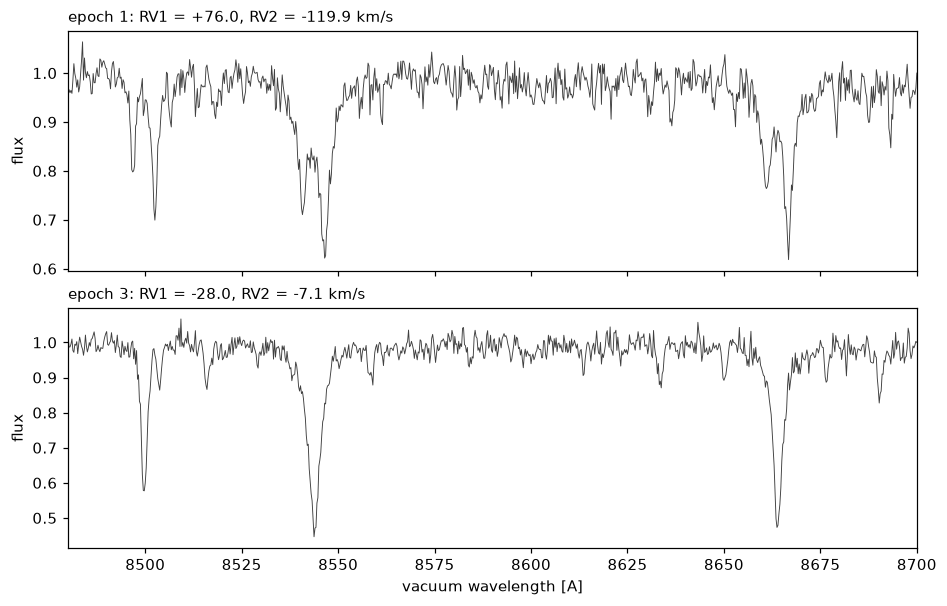

In [4]:
separation = np.abs(truth.velocities[0] - truth.velocities[1])
far, near = int(np.argmax(separation)), int(np.argmin(separation))

fig, axes = plt.subplots(2, 1, figsize=(8.5, 5.4), sharex=True)
for ax, i in zip(axes, (far, near), strict=True):
    epoch = dataset[i]
    ax.plot(epoch.wave, epoch.flux, lw=0.6, color="0.25")
    v1, v2 = truth.velocities[:, i]
    ax.set_title(f"epoch {i}: RV1 = {v1:+.1f}, RV2 = {v2:+.1f} km/s", fontsize=10, loc="left")
    ax.set_ylabel("flux")
axes[0].set_xlim(8480.0, 8700.0)
axes[1].set_xlabel("vacuum wavelength [A]")
fig.set_layout_engine("constrained")

## Step 3: analyse the one binary

### Disentangle

The `Disentangler` takes a declaration: the components with their light fractions, the
orbit priors, the line-spread width and, for these spectra, the noise correlation the
delivery introduced. It recovers the two component spectra and the orbit jointly. The
period is declared known, as a Gaia period would be. The semi-amplitudes and the
eccentricity are free.

In [5]:
dis = ab.Disentangler(
    dataset,
    components=[ab.Star("primary", LIGHT[0]), ab.Star("secondary", LIGHT[1])],
    orbit=ab.Orbit(
        period=ab.Known(PERIOD, 1e-3 * PERIOD),
        k=ab.Between([20.0, 20.0], [160.0, 160.0], start_at=[70.0, 110.0]),
        ecc=ab.Between(0.0, 0.5),
    ),
    lsf={"RVS": ab.LSF(sigma_kms=delivered)},
    dv_kms=3.0,
    noise_correlation={"RVS": float(np.mean(truth.delivery.lag1))},
)

t0 = time.perf_counter()
fit = dis.fit()
print(f"[{time.perf_counter() - t0:.0f} s, including JAX compilation]")
print(
    f"K1 = {fit.star('primary')['k']:.2f} km/s (injected {k1:.2f}), "
    f"K2 = {fit.star('secondary')['k']:.2f} km/s (injected {k2:.2f}), "
    f"e = {float(fit.orbit()['ecc']):.3f} (injected {ECC}), residual z rms {fit.z_rms:.3f}"
)

[427 s, including JAX compilation]


K1 = 87.34 km/s (injected 87.70), K2 = 95.11 km/s (injected 95.00), e = 0.092 (injected 0.1), residual z rms 0.978


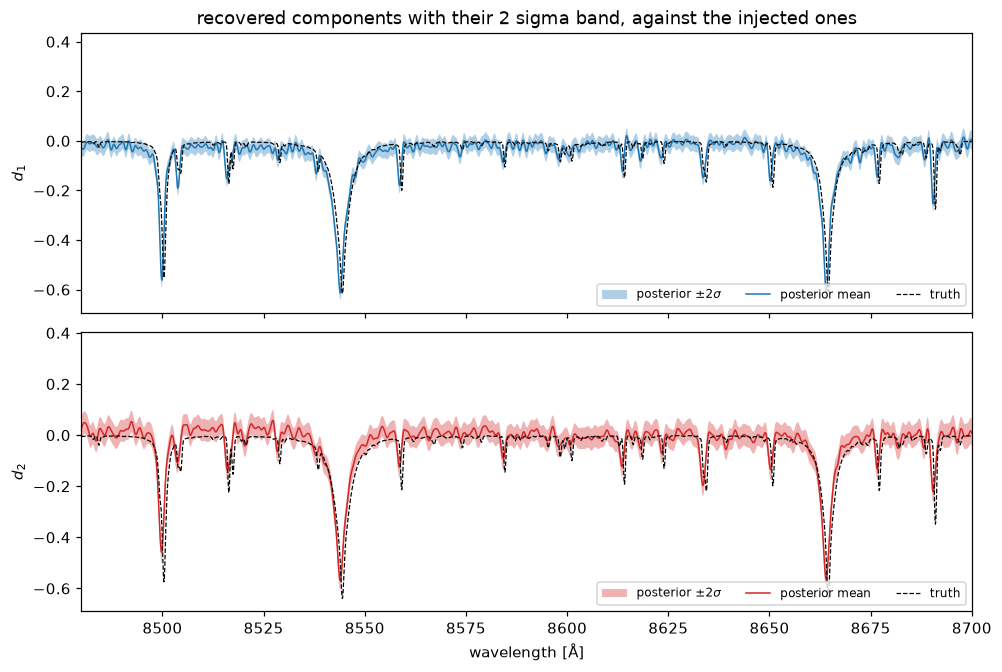

In [6]:
truth_on_model = np.stack(
    [np.interp(dis.grid.wave, grid.wave, c, left=0.0, right=0.0) for c in components]
)
fig, axes = ab.plot_spectra(dis.grid, fit.spectra(), std=fit.std(), truth=truth_on_model)
axes[0].set_title("recovered components with their 2 sigma band, against the injected ones")
axes[0].set_xlim(8480.0, 8700.0)
fig.set_layout_engine("constrained")

### Epoch velocities, and the orbit from them

The disentangling infers the orbit from the spectra directly and does not measure a
velocity per epoch. The benchmark also needs epoch velocities, which an archive user would
produce and an orbit code takes as input. `measure_velocities` correlates every epoch
against the recovered components (TODCOR, Zucker & Mazeh 1994), and `fit_rv_orbit` fits a
Keplerian to the table. The two routes fail differently, so the report tabulates both.

The velocities are relative to the recovered components, which are at the systemic
velocity the disentangling does not fit. In the figure the injected values (ticks) are
18 km/s below every measured point, on both components. The orbit fit therefore includes
one zero point per component, and the systemic velocity is measured in the next step.

Keplerian fit to 20 velocities of 2 component(s): chi2 10.20 for 12 dof (errors rescaled by sqrt(0.850))
  P      = 3.999169 +- 0.007698 d
  T_conj = 2457001.23179 +- 0.00372
  e      = 0.0922 +- 0.0029
  omega  = 37.61 +- 1.94 deg
  K_primary = 87.3632 +- 0.2729 km/s   gamma_primary = +0.0043 +- 0.2354 km/s   rms 0.4493 km/s
  K_secondary = 94.9946 +- 0.4737 km/s   gamma_secondary = +0.0213 +- 0.3691 km/s   rms 0.8429 km/s
  systemic velocity: one per component
  q = K_primary/K_secondary = 0.9197;  M_primary sin^3 i = 1.2923 Msun, M_secondary sin^3 i = 1.1885 Msun


Text(0.5, 1.0, 'TODCOR velocities against the recovered components; ticks: injected')

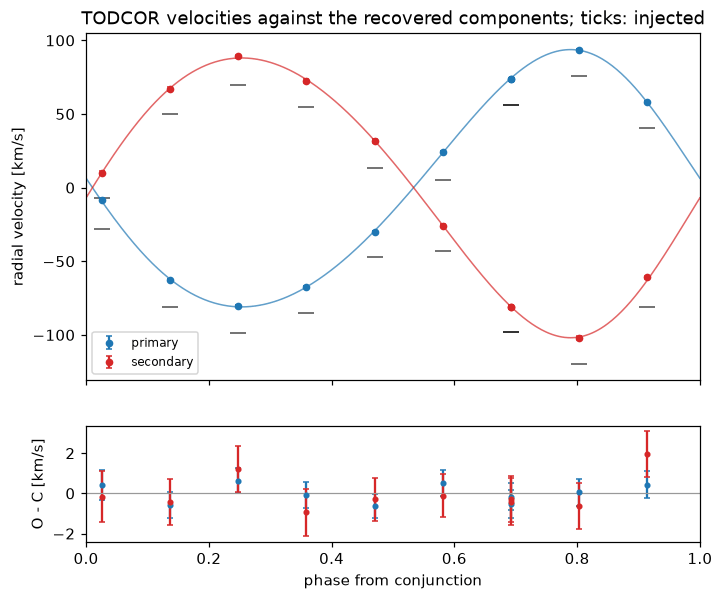

In [7]:
table = fit.measure_velocities()
rv_orbit = ab.fit_rv_orbit(table, period=PERIOD)
print(rv_orbit.summary())

fig, axes = ab.plot_velocity_table(table, orbit=rv_orbit, truth=truth.velocities)
axes[0].set_title("TODCOR velocities against the recovered components; ticks: injected")

### Labels

The last stage compares library templates with the epoch spectra through the
disentangling's statistics and fits the temperature, gravity, metallicity and rotation of
each star, together with the light fraction. The recovered components are at the systemic
velocity, which the disentangling does not measure, so each template's frame offset is
also fitted, after a scan over trial offsets. The fitted offset is the systemic velocity
and makes the pipeline's velocities absolute. The oracle tier of the benchmark gives this
fit narrow priors around the injected values. The other tiers give it the library box, as
here.

In [8]:
lo, hi = library.bounds["teff"]
stars = {
    name: ab.StarLabels(
        library=library,
        teff=ab.Between(lo, hi),
        logg=ab.Between(*library.bounds["logg"]),
        vsini=ab.Between(1.0, 60.0),
        v_kms=ab.Between(-150.0, 150.0),
    )
    for name in ("primary", "secondary")
}
t0 = time.perf_counter()
labels = fit.match_labels(stars, scan_velocities=np.arange(-150.0, 150.1, 25.0))
print(f"[{time.perf_counter() - t0:.0f} s]")
for name, injected, v in zip(("primary", "secondary"), (PRIMARY, SECONDARY), VSINI, strict=True):
    got = labels.labels[name]
    print(
        f"{name:9s} Teff {got['teff']:6.0f} K (injected {injected['teff']:.0f}), "
        f"log g {got['logg']:.2f} ({injected['logg']}), vsini {got['vsini']:.1f} km/s ({v}), "
        f"frame offset {got['v_kms']:+.1f} km/s (gamma {GAMMA:+.1f})"
    )

[33 s]
primary   Teff   6174 K (injected 6100), log g 4.36 (4.2), vsini 10.6 km/s (12.0), frame offset -18.2 km/s (gamma -18.0)
secondary Teff   5670 K (injected 5700), log g 4.28 (4.3), vsini 12.0 km/s (11.0), frame offset -18.2 km/s (gamma -18.0)


The system above has stars, an orbit and a S/N that were set manually, and epochs spaced
evenly over one period, a cadence at which no real star is observed. The benchmark
replaces each of those choices with a draw.

## Step 4: a population

`draw_population` draws binaries from the field's distributions as a magnitude-limited
survey observes them. It uses the orbits and mass ratios of Moe & Di Stefano (2017), a
dwarf sequence for the stars, the eclipse geometry for the inclinations, and the scanning
law for the number of transits. The separation floor represents Gaia's double-lined
selection. A pair whose lines are never separated by more than one and a half resolution
elements is not in the double-lined sample either.

12 systems (2 eclipsing), sources parametric
  P [d]        quartiles 1.59 / 11.3 / 32.6
  e            quartiles 0 / 0.204 / 0.552
  K1 + K2 [km/s] quartiles 83.7 / 156 / 226
  q = M2/M1    quartiles 0.861 / 0.957 / 0.977
  F2/F1 (RVS)  quartiles 0.611 / 0.837 / 0.913
  Teff1 [K]    quartiles 6.28e+03 / 6.41e+03 / 6.71e+03
  G_RVS        quartiles 9.18 / 9.57 / 10.1
  transits     quartiles 14 / 32.5 / 44.2


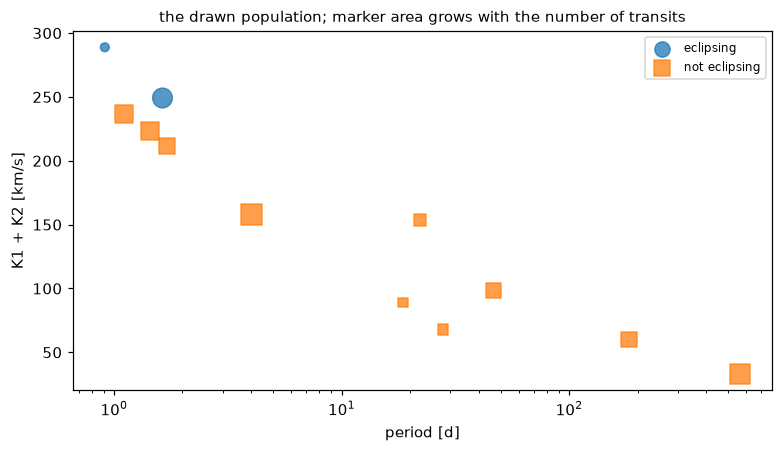

In [9]:
systems = draw_population(12, kind="mixed", seed=1, library=library, min_separation_kms=40.0)
print(population_summary(systems))

fig, ax = plt.subplots(figsize=(7.0, 4.0))
for eclipsing, marker, label in ((True, "o", "eclipsing"), (False, "s", "not eclipsing")):
    chosen = [s for s in systems if s.eclipsing == eclipsing]
    ax.scatter(
        [s.period for s in chosen],
        [s.k1 + s.k2 for s in chosen],
        s=[12 + 3 * s.n_transits for s in chosen],
        marker=marker,
        alpha=0.75,
        label=label,
    )
ax.set_xscale("log")
ax.set_xlabel("period [d]")
ax.set_ylabel("K1 + K2 [km/s]")
ax.set_title("the drawn population; marker area grows with the number of transits", fontsize=10)
ax.legend(fontsize=8)
fig.set_layout_engine("constrained")

## Step 5: the benchmark

Every system is simulated once, with the S/N that follows from its G_RVS and the epochs
the scanning law gives it, and the same spectra are run through the pipeline under each
knowledge tier:

| tier | what the analysis is given |
|---|---|
| `oracle` | the period, the conjunction, the elements and narrow label priors: the upper bound |
| `eclipsing` | an eclipse ephemeris and a light-curve light ratio, the elements free |
| `orbit` | a Gaia period only; the light ratio is measured |
| `blind` | nothing: a period search from library templates |

The benchmark is one command, `scripts/gaia_rvs_benchmark.py`, which draws or reads a
population, simulates it, runs the pipeline under each tier in worker processes, and
writes the report. `albireo.run_benchmark` runs the same benchmark from Python. The full
run, forty systems under all four tiers with the script's default optimiser budgets, takes
hours. The run below gives the script three systems from the draw above, chosen to span it
and to finish. They are a 1.1-day circular twin, a 4-day pair of mild eccentricity, and a
1.7-day pair whose secondary is a quarter as bright as its primary, with 41, 59 and 33
transits. The run uses two tiers: `oracle`, the upper bound, and `orbit`, with only a Gaia
period. The semi-amplitude prior is capped at 150 km/s, above the largest in the
population, which halves the width of the band the disentangling solves. The blind tier's
period search is left to the full run, where its recovery rate is measured on thirty-odd
systems. Three systems would not constrain that rate. The numbers below illustrate the
workflow and are not a result. The results of the full runs are recorded in the
[benchmarks](../benchmarks.md) and summarised under "Results of the full runs" below.

The script runs in its own process, as it would from a shell, so the notebook's JAX state
does not affect it.

In [10]:
out = Path(tempfile.gettempdir()) / "albireo_rvs_notebook"
out.mkdir(exist_ok=True)
chosen = [s for s in systems if s.name in ("mixed-0003", "mixed-0004", "mixed-0007")]
for s in chosen:
    print(
        f"{s.name}: P {s.period:.2f} d, e {s.ecc:.2f}, K {s.k1:.0f} + {s.k2:.0f} km/s, "
        f"F2/F1 {s.light_ratio:.2f}, G_RVS {s.grvs:.1f}, {s.n_transits} transits"
    )
write_population(out / "population.json", chosen)

command = [
    sys.executable,
    "scripts/gaia_rvs_benchmark.py",
    "--population",
    str(out / "population.json"),
    "--tiers",
    "oracle",
    "orbit",
    "--k-max",
    "150",
    "--no-plots",
    "--out",
    str(out),
    "--title",
    "three systems, two tiers",
]
print("$", " ".join(command[1:]))
t0 = time.perf_counter()
done = subprocess.run(command, capture_output=True, text=True, encoding="utf-8")
print(f"[{(time.perf_counter() - t0) / 60:.1f} min, exit code {done.returncode}]\n")
print("\n".join(done.stdout.strip().splitlines()[-6:]))

rows = collect(out)


def pct(value):
    return "   n/a" if value is None else f"{100 * value:+6.1f}%"


print()
for row in rows:
    print(
        f"  {row['star']:22s} {row['status']:6s} dK1/K1 {pct(row.get('k_A_rel_dis'))}  "
        f"dK2/K2 {pct(row.get('k_B_rel_dis'))}  (disentangling)"
    )

mixed-0003: P 1.11 d, e 0.00, K 117 + 120 km/s, F2/F1 0.97, G_RVS 9.3, 41 transits
mixed-0004: P 4.04 d, e 0.18, K 77 + 81 km/s, F2/F1 0.78, G_RVS 8.2, 59 transits
mixed-0007: P 1.71 d, e 0.00, K 87 + 124 km/s, F2/F1 0.24, G_RVS 11.3, 33 transits
$ scripts/gaia_rvs_benchmark.py --population C:\Users\thari\DOCUME~1\temp\albireo_rvs_notebook\population.json --tiers oracle orbit --k-max 150 --no-plots --out C:\Users\thari\DOCUME~1\temp\albireo_rvs_notebook --title three systems, two tiers


[57.3 min, exit code 0]

  mixed-0007__oracle: P 1.71141 d, K_A 85.40, K_B 119.48 km/s (711 s, 6 flag(s))
  mixed-0007__orbit: P 1.71142 d, K_A 85.60, K_B 115.76 km/s (487 s, 5 flag(s))

benchmark finished in 56.9 min; report at C:\Users\thari\DOCUME~1\temp\albireo_rvs_notebook\report.md
  oracle: 3/3 ok, median |dK1/K1| 0.22%, K1 pull rms 0.98
  orbit: 3/3 ok, median |dK1/K1| 0.08%, K1 pull rms 0.75

  mixed-0003__oracle     ok     dK1/K1   +0.1%  dK2/K2   +0.1%  (disentangling)
  mixed-0003__orbit      ok     dK1/K1   -0.0%  dK2/K2   +0.9%  (disentangling)
  mixed-0004__oracle     ok     dK1/K1   +0.0%  dK2/K2   -0.4%  (disentangling)
  mixed-0004__orbit      ok     dK1/K1   -0.6%  dK2/K2   -0.9%  (disentangling)
  mixed-0007__oracle     ok     dK1/K1   -5.3%  dK2/K2   -0.9%  (disentangling)
  mixed-0007__orbit      ok     dK1/K1   -2.6%  dK2/K2   -5.4%  (disentangling)


### Read the report

`report.md` is written into the output directory beside `rows.csv` (one line per star run
with the injected values and every metric), `velocities.csv` (every epoch velocity with
its injected value) and `summary.json` (the statistics of every tier). The next cell reads
the key numbers from `summary.json`. Each entry is the median absolute error over the
systems of the tier, A the primary and B the secondary. The epoch-velocity rows instead
pool the usable epochs of all the systems: the error is the median absolute difference
from the injected velocity, and a pull is that difference divided by the quoted error, so
calibrated errors give a pull rms near one.

In [11]:
import json

from IPython.display import Markdown

KEY_NUMBERS = {  # row label: the statistics of summary.json in the row
    "K1, K2 error, disentangling": "{k_A_abs_rel_dis:.2%}, {k_B_abs_rel_dis:.2%}",
    "K1, K2 error, orbit fitted to the velocity table": "{k_A_abs_rel:.2%}, {k_B_abs_rel:.2%}",
    "eccentricity error": "{ecc_abs_err:.3f}",
    "systemic velocity error [km/s]": "{gamma_abs_err_A:.2f}",
    "epoch velocity error, A, B [km/s]": "{median_abs_A:.2f}, {median_abs_B:.2f}",
    "epoch velocity pull rms, A, B": "{pull_rms_A:.2f}, {pull_rms_B:.2f}",
    "Teff error, A, B [K]": "{teff_abs_err_A:.0f}, {teff_abs_err_B:.0f}",
    "log g error, A [dex]": "{logg_abs_err_A:.2f}",
    "v sin i error, A [km/s]": "{vsini_abs_err_A:.2f}",
    "light fraction error, A, label fit": "{light_abs_err_A:.3f}",
    "wall-clock time per star [s]": "{seconds_median:.0f}",
}

summary = json.loads((out / "summary.json").read_text(encoding="utf-8"))
# per tier: the median of every per-system statistic, and the pooled epoch statistics
medians = {
    tier: {k: v["median"] for k, v in stats.items() if isinstance(v, dict) and "median" in v}
    | summary["epoch_velocities"][tier]
    for tier, stats in summary["tiers"].items()
}
lines = ["| quantity | " + " | ".join(medians) + " |", "|---|" + "---|" * len(medians)]
for label, row in KEY_NUMBERS.items():
    lines.append(f"| {label} | " + " | ".join(row.format(**m) for m in medians.values()) + " |")
Markdown("\n".join(lines))

| quantity | oracle | orbit |
|---|---|---|
| K1, K2 error, disentangling | 0.08%, 0.35% | 0.61%, 0.93% |
| K1, K2 error, orbit fitted to the velocity table | 0.22%, 0.28% | 0.08%, 0.54% |
| eccentricity error | 0.004 | 0.004 |
| systemic velocity error [km/s] | 0.42 | 0.37 |
| epoch velocity error, A, B [km/s] | 0.86, 0.94 | 0.86, 1.02 |
| epoch velocity pull rms, A, B | 1.01, 1.15 | 1.02, 1.14 |
| Teff error, A, B [K] | 61, 118 | 120, 62 |
| log g error, A [dex] | 0.09 | 0.22 |
| v sin i error, A [km/s] | 0.31 | 0.34 |
| light fraction error, A, label fit | 0.005 | 0.007 |
| wall-clock time per star [s] | 589 | 487 |

In this run:

- **Semi-amplitudes.** The two systems observed at a S/N of 27 and 47 per detector pixel
  have K1 and K2 within 1 percent of the injected values under both tiers. The third, at
  G_RVS = 11.3 (a S/N of 8) with a flux ratio of 0.24, is within 5.4 percent.
- **Epoch velocities.** The median absolute error is 0.9 to 1.0 km/s, and the pull rms of
  1.0 to 1.2 shows that the quoted errors are calibrated.
- **Labels.** The temperatures of the two brighter systems are within 120 K, and those of
  the third are 210 to 790 K off. With only the period declared, the label fit measures
  the primary's light fraction to 0.007, where the correlation against library templates
  that precedes the disentangling is 0.048 off.
- **Twins.** The twin pair is recovered in the other order under the `orbit` tier. The
  report flags the exchange and evaluates the pair in that order.

All three systems are short-period pairs whose lines separate by more than 180 km/s, which
is the favourable case. The first table of `report.md` gives every statistic with its 16th
to 84th percentile range over the systems that completed:

In [12]:
text = (out / "report.md").read_text(encoding="utf-8")
start = text.index("| quantity |", text.index("## Recovery by tier"))
Markdown(text[start : text.index("\n\n", start)])

| quantity | oracle | orbit |
|---|---|---|
| completed / planned | 3 / 3 | 3 / 3 |
| abs(dK1 / K1) [%], disentangling | 0.0799 (0.0523 to 3.65) | 0.605 (0.221 to 1.99) |
| abs(dK2 / K2) [%], disentangling | 0.352 (0.214 to 0.7) | 0.931 (0.906 to 3.95) |
| K1 within 1%, disentangling | 67% | 67% |
| K2 within 1%, disentangling | 100% | 67% |
| K1 within 5%, disentangling | 67% | 100% |
| K2 within 5%, disentangling | 100% | 67% |
| abs(dK1 / K1) [%], velocity table | 0.22 (0.107 to 1.32) | 0.0751 (0.0576 to 1.11) |
| abs(dK2 / K2) [%], velocity table | 0.275 (0.212 to 2.73) | 0.536 (0.403 to 4.85) |
| K1 within 1%, velocity table | 67% | 67% |
| K1 within 5%, velocity table | 100% | 100% |
| K2 within 5%, velocity table | 100% | 67% |
| K1 pull rms, velocity table | 0.976 | 0.746 |
| K2 pull rms, velocity table | 1.12 | 3.4 |
| K1 pull within 1, velocity table | 33% | 67% |
| K2 pull within 2, velocity table | 100% | 67% |
| components recovered in the other order | 0% | 33% |
| abs(dP / P) from the table | 6.65e-07 (3.24e-07 to 4.58e-06) | 7.73e-07 (7.73e-07 to 5.89e-06) |
| abs(de) | 0.00399 (0.00272 to 0.00609) | 0.00421 (0.00231 to 0.00942) |
| abs(d omega) [deg] | 0.0243 (0.0243 to 0.0243) | 0.469 (0.469 to 0.469) |
| abs(d t_conj) [phase] | 0.000841 (0.000558 to 0.00504) | 0.0101 (0.00328 to 0.343) |
| abs(d gamma) A [km/s] | 0.419 (0.157 to 0.429) | 0.372 (0.186 to 0.414) |
| epoch velocity rms, A [km/s] | 1.97 (1.07 to 4.27) | 1.76 (1.03 to 4.03) |
| epoch velocity rms, B [km/s] | 2.04 (1.27 to 9.69) | 1.79 (1.13 to 6.4) |
| epoch velocity pull rms, A | 1.05 (0.955 to 1.06) | 0.996 (0.94 to 1.07) |
| epoch velocity pull rms, B | 0.906 (0.885 to 1.25) | 1.16 (1.03 to 1.22) |
| secondary detected per epoch (dchi2 > 25) | 1 (0.67 to 1) | 1 (0.856 to 1) |
| spectrum correlation, A | 0.942 (0.9 to 0.952) | 0.941 (0.89 to 0.95) |
| spectrum correlation, B | 0.879 (0.806 to 0.927) | 0.858 (0.719 to 0.92) |
| spectrum pull rms, A | 2.68 (2.14 to 2.84) | 1.98 (1.83 to 2.05) |
| EW ratio, metal windows, A | 1.29 (1.13 to 1.47) | 1.13 (1.02 to 1.31) |
| EW ratio, Ca II triplet, A | 1.11 (1.05 to 1.15) | 0.996 (0.946 to 1.18) |
| EW ratio, metal windows, B | 0.306 (0.0305 to 0.724) | 0.834 (0.172 to 0.955) |
| abs(dTeff) A [K] | 60.8 (25.9 to 165) | 120 (45.9 to 198) |
| abs(dTeff) B [K] | 118 (40.2 to 242) | 61.9 (20.7 to 556) |
| abs(dlog g) A | 0.0901 (0.0329 to 0.177) | 0.218 (0.0736 to 0.224) |
| abs(dvsini) A [km/s] | 0.307 (0.262 to 0.441) | 0.343 (0.127 to 1.34) |
| abs(dlight) from the label fit, A | 0.00531 (0.00271 to 0.00667) | 0.00664 (0.00309 to 0.00835) |
| abs(dlight) as declared, A | 0 (0 to 0) | 0.0482 (0.0317 to 0.0503) |
| residual z rms | 0.994 (0.991 to 0.995) | 0.99 (0.989 to 0.991) |
| period search recovered within 2% | n/a | n/a |
| wall per star [s] | 589 (555 to 672) | 487 (430 to 614) |

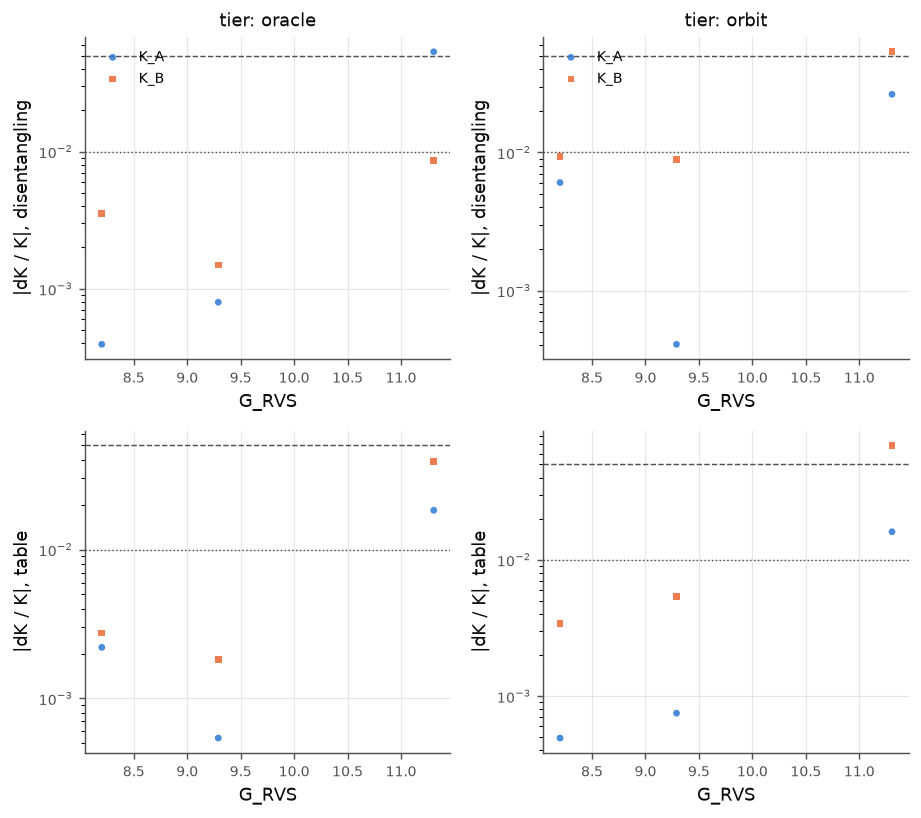

In [13]:
from IPython.display import Image

Image(filename=out / "figures" / "k_recovery.png", width=720)

The full benchmark is the same command with a drawn population and the default budgets,
and an interrupted run resumes from its output directory:

```
python scripts/gaia_rvs_benchmark.py --n 40 --jobs 8 --out bench/rvs
python scripts/gaia_rvs_benchmark.py --report-only --out bench/rvs     # regenerate the report
```

`--cadence gost` replaces the drawn transit count with the forecast of the Gaia
Observation Forecast Tool for each system's position. `--product dr3` delivers the DR3
mean-spectrum grid instead. `--debcat` or `--gaia-sb2` builds the population from real
eclipsing or double-lined binaries rather than from the parametric draw.

## Results of the full runs

The recorded runs analyse 33 simulated systems under all four tiers. Nineteen are drawn
from the field distributions as in step 4, with periods of 1.3 to 844 d, 11 to 100
transits and a S/N of 9 to 98 per pixel and epoch. Fourteen are double-lined orbits of the
Gaia DR3 catalogue, with periods of 0.5 to 30 d and a S/N of 14 to 97, simulated at their
DR3 counts of 10 to 25 transits, which are fewer than DR4 will have. The numbers in this
section are from the third run, the most recent. Its tables and those of the two runs
before it are in the [benchmarks](../benchmarks.md).

The largest velocity separation of the orbit, (K1 + K2)(1 + e), orders the recovery more
than the magnitude or the number of transits does. The table gives the number of systems
with both semi-amplitudes of the disentangling within 5 percent of the injected values, on
either side of a separation of 100 km/s, which is about four times the FWHM of the
line-spread function (26 km/s). The median errors of K1 and K2 are in brackets.

| tier | declared to the analysis | separation above 100 km/s | below 100 km/s |
|---|---|---|---|
| `oracle` | the orbit and the light ratio | 21 of 22 (0.36, 0.42 %) | 1 of 11 |
| `orbit` | the period | 19 of 22 (0.65, 0.75 %) | 2 of 11 |
| `blind` | nothing | 15 of 22 (1.0, 1.6 %) | 0 of 11 |

- **Semi-amplitudes.** With the period declared, as a Gaia orbit or a light curve gives
  it, 19 of the 22 systems above 100 km/s are within 5 percent, on 10 to 100 transits. The
  three exceptions are a 0.54-day contact pair of stars rotating at 100 km/s, a 0.58-day
  pair with a primary rotating at 122 km/s and a secondary with 7 percent of the light,
  and a 45-day pair at a S/N of 10 with a flux ratio of 0.17.
- **Period.** The `blind` tier finds the period within 2 percent for 16 of the 22 systems
  above 100 km/s and for 2 of the 11 below. Five of the six it misses above 100 km/s are
  twins with a mass ratio above 0.97. A known period should be declared.
- **Epoch velocities.** Under the `oracle` and `orbit` tiers the median absolute error of
  an epoch velocity is 0.6 to 0.8 km/s on the Gaia orbits and 0.9 to 1.3 km/s on the
  field systems. The median pull rms of a system is 1.0 to 1.4, and 83 to 92 percent of
  the epochs are within three quoted errors.
- **Faint secondaries.** The disentangling recovers a companion that the correlation at
  single epochs does not. For a secondary with 5 percent of the light (P = 117 d, a S/N of
  98, 80 transits) both semi-amplitudes of the disentangling are within 0.5 percent under
  every tier, and the orbit fitted to the velocity table gives the secondary a
  semi-amplitude of zero.
- **Labels and light ratio.** Measured afterwards on 22 products of the third run, with
  the comparison against the epochs that is now the default, the median errors are 60 K in
  temperature, 0.04 dex (primaries) and 0.13 dex (secondaries) in surface gravity, and
  0.006 dex in metallicity. Under the `orbit` tier the light fraction is measured to
  0.011.
- **Cases not recovered.** Below 100 km/s the lines never separate by four resolution
  elements, and the semi-amplitudes are not recovered even with the orbit declared. The
  exception is a 7.7-day pair of slow rotators at a S/N of 97, recovered to 1 percent at a
  separation of 53 km/s. Of the five systems with a component rotating at 85 to 122 km/s,
  one is within 5 percent under the `orbit` tier. Primaries above 7000 K are outside the
  library box these runs use.
- **Cost.** One star under one tier takes 7 to 15 minutes on a 32-thread desktop running
  three stars at once.

The third run predates the label comparison and the velocity-table changes that the run in
this notebook includes. No full run has been repeated with them.

## Limitations of the simulation

The simulation omits three effects. The templates and the injected spectra come from the
same grid, so template mismatch is absent. A real star's lines are not BOSZ's, and the
label errors here are a lower limit. The line-spread function is a Gaussian at the nominal
resolving power, unlike the DPAC model, and the smoothing the analysis declares is the
mean over the band and the epochs. The epochs follow the scanning law's statistics rather
than its phase, so a real star's period aliases are not reproduced. The report measures
how the recovery scales with brightness, transit count, separation and light ratio, and
where the quoted errors are calibrated.

References: Bohlin, R. C., et al. 2017, AJ, 153, 234; Cropper, M., et al. 2018, A&A, 616,
A5; Mészáros, Sz., et al. 2024, PASP, 136, 4504; Moe, M. & Di Stefano, R. 2017, ApJS, 230,
15; Zucker, S. & Mazeh, T. 1994, ApJ, 420, 806.